# Class 5 - Logistic Regression

In [78]:
# --- Setup
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Modeling
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

Let's generate some data that has an outcome variable that is binary (yes/no) 

In [79]:
# Set reproducibility
pd.set_option('display.float_format', '{:.2f}'.format)


rng = np.random.default_rng(42)

N = 10_000

# --- Simulate income (annual USD) ---
# Mixture of two normals to add some heterogeneity
income = np.clip(
    rng.normal(70_000, 20_000, N) * (rng.random(N) > 0.2) +
    rng.normal(40_000, 10_000, N) * (rng.random(N) <= 0.2),
    10_000, 250_000
)

# --- Simulate student status (Yes/No) ---
student = rng.binomial(1, 0.30, N)  # about 30% "Yes"

# --- Simulate balance (average CC balance after payment) ---
base_balance = rng.normal(1_000, 500, N)  # core distribution
# Non-students slightly higher, with extra noise
balance = base_balance + (1 - student) * 300 + rng.normal(0, 200, N)
balance = np.clip(balance, 0, 5_000)

# --- Latent default probability using logistic model ---
# Aim for ~2–4% default rate
b0 = -6.5
b_balance = 0.0022   # higher balance → higher risk
b_income = -0.000006 # higher income → lower risk
b_student = -0.25     # students a bit riskier

linpred = b0 + b_balance * balance + b_income * income + b_student * student
p_default = 1 / (1 + np.exp(-linpred))

# --- Realize default as Bernoulli draw ---
default = rng.binomial(1, p_default, N)

# --- Package into DataFrame with ISLR-like factors ---
df = pd.DataFrame({
    "default": np.where(default == 1, "Yes", "No"),
    "student": np.where(student == 1, "Yes", "No"),
    "balance": np.round(balance, 2),
    "income": np.round(income, 2),
})

# Quick summary stats
print("Default rate:", (df["default"] == "Yes").mean())
print("Student share:", (df["student"] == "Yes").mean())
print("Rows:", (df.shape[1]))
print(df.head())

Default rate: 0.0265
Student share: 0.3005
Rows: 4
  default student  balance    income
0      No      No  1905.04  76094.34
1      No      No  1677.96 102957.10
2      No      No  1192.65 137960.58
3      No      No  1768.44  10000.00
4      No     Yes  1243.93  30979.30


In [80]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
pd.set_option('display.float_format', '{:.6f}'.format)

df["default_binary"] = (df["default"].str.lower() == "yes").astype(int)

# OLS: default_binary ~ balance
ols_mod = smf.ols("default_binary ~ balance", data=df).fit()
print(ols_mod.summary())

                            OLS Regression Results                            
Dep. Variable:         default_binary   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                     381.1
Date:                Wed, 24 Sep 2025   Prob (F-statistic):           2.54e-83
Time:                        20:57:43   Log-Likelihood:                 4285.0
No. Observations:               10000   AIC:                            -8566.
Df Residuals:                    9998   BIC:                            -8552.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0414      0.004    -10.844      0.0

In [81]:
coef_df = pd.DataFrame({
    "coef":      ols_mod.params,
    "std_err":   ols_mod.bse,
    "t":         ols_mod.tvalues,
    "p>|t|":     ols_mod.pvalues,
    "ci_low":    ols_mod.conf_int()[0],
    "ci_high":   ols_mod.conf_int()[1],
}).round(6)
print(coef_df)

               coef  std_err          t    p>|t|    ci_low   ci_high
Intercept -0.041423 0.003820 -10.843861 0.000000 -0.048911 -0.033935
balance    0.000056 0.000003  19.521349 0.000000  0.000050  0.000062


     preds     balance  default_binary
0 0.065442 1905.040000               0
1 0.052704 1677.960000               0
2 0.025480 1192.650000               0
3 0.057779 1768.440000               0
4 0.028357 1243.930000               0


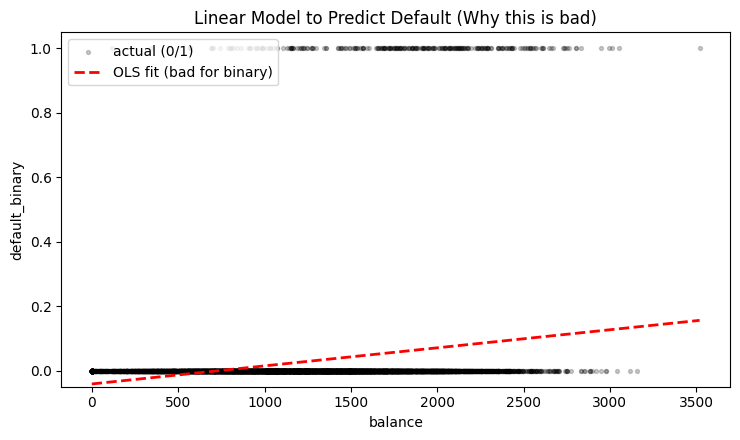

In [82]:

# Predictions dataframe 
preds_DF = pd.DataFrame({
    "preds": ols_mod.predict(df),
    "balance": df["balance"].values,
    "default_binary": df["default_binary"].values
})
print(preds_DF.head())

# Build regression line from coefficients 
intercept = ols_mod.params["Intercept"]
slope = ols_mod.params["balance"]

# x range for straight line
x_line = np.linspace(df["balance"].min(), 
                     df["balance"].max(), 200)
y_line = intercept + slope * x_line

# Plot
plt.figure(figsize=(7.5,4.5))
plt.scatter(df["balance"], df["default_binary"], s=8, alpha=0.2, color="black", label="actual (0/1)")
plt.plot(x_line, y_line, linestyle="--", color="red", linewidth=2, label="OLS fit (bad for binary)")
plt.xlabel("balance")
plt.ylabel("default_binary")
plt.ylim(-0.05, 1.05)
plt.legend(loc="upper left")
plt.title("Linear Model to Predict Default (Why this is bad)")
plt.tight_layout()
plt.show()

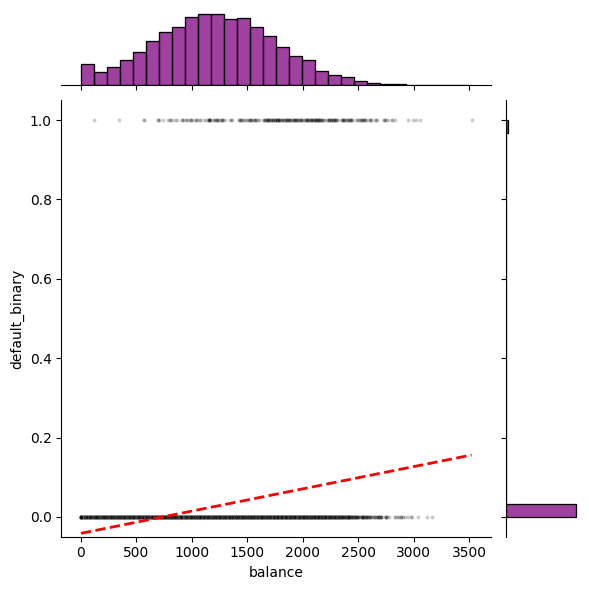

In [83]:
import seaborn as sns 

# --- Plot with marginal histograms ---
g = sns.JointGrid(data=preds_DF, x="balance", y="default_binary", height=6)

# Scatter points
g.plot_joint(sns.scatterplot, color="black", s=8, alpha=0.2)

# Regression line (like geom_abline)
x_line = np.linspace(df["balance"].min(), df["balance"].max(), 200)
y_line = intercept + slope * x_line
g.ax_joint.plot(x_line, y_line, color="red", linestyle="--", linewidth=2)

# Marginal histograms
g.plot_marginals(sns.histplot, color="purple", bins=30)

# Labels and formatting
g.ax_joint.set_ylabel("default_binary")
g.ax_joint.set_xlabel("balance")
g.ax_joint.set_ylim(-0.05, 1.05)
plt.show()

     preds        income  default_binary
0 0.065442  76094.340000               0
1 0.052704 102957.100000               0
2 0.025480 137960.580000               0
3 0.057779  10000.000000               0
4 0.028357  30979.300000               0


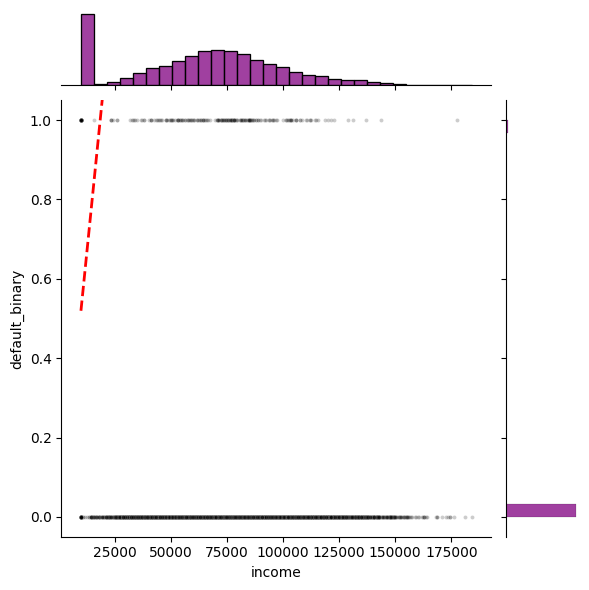

In [84]:
import seaborn as sns 
# Predictions dataframe 
preds_DF = pd.DataFrame({
    "preds": ols_mod.predict(df),
    "income": df["income"].values,
    "default_binary": df["default_binary"].values
})
print(preds_DF.head())
# --- Plot with marginal histograms ---
g = sns.JointGrid(data=preds_DF, x="income", y="default_binary", height=6)

# Scatter points
g.plot_joint(sns.scatterplot, color="black", s=8, alpha=0.2)

# Regression line (like geom_abline)
x_line = np.linspace(df["income"].min(), df["income"].max(), 200)
y_line = intercept + slope * x_line
g.ax_joint.plot(x_line, y_line, color="red", linestyle="--", linewidth=2)

# Marginal histograms
g.plot_marginals(sns.histplot, color="purple", bins=30)

# Labels and formatting
g.ax_joint.set_ylabel("default_binary")
g.ax_joint.set_xlabel("income")
g.ax_joint.set_ylim(-0.05, 1.05)
plt.show()

## Why not regression?

If we regress a 0/1 outcome on features using OLS:

$$
Y_i = \beta_0 + \beta_1 \,\text{balance}_i + \varepsilon_i,\quad Y_i \in \{0,1\}
$$

OLS treats $(Y)$ as continuous, which leads to problems:
1. **Predictions outside $([0,1]$)** (not valid probabilities).
2. **Heteroskedastic errors**: $(\operatorname{Var}(\varepsilon_i) = p_i(1-p_i))$ depends on $(X)$.
3. **Nonlinearity**: true probability–feature relationship is S-shaped, not linear.

We’ll still run OLS briefly to see the summary, then switch to **logistic regression**.

In [85]:
# 1) OLS can predict outside [0, 1]
pred = ols_mod.predict(df[["balance"]].assign(Intercept=1))
print("Predicted min/max:", pred.min(), pred.max())
print("Share of predictions <0 or >1:", np.mean((pred < 0) | (pred > 1)))

# 2) Heteroskedasticity (variance of errors depends on p(1-p))
#    Breusch–Pagan test: large LM-stat / small p-value => heteroskedastic
resid = ols_mod.resid
exog  = sm.add_constant(df["balance"])
lm_stat, lm_p, f_stat, f_p = het_breuschpagan(resid, exog)
print(f"Breusch–Pagan LM={lm_stat:.2f}, p={lm_p:.3g} (smaller p => hetskedastic)")

Predicted min/max: -0.04142274493792687 0.1559920029689979
Share of predictions <0 or >1: 0.1996
Breusch–Pagan LM=363.43, p=5.05e-81 (smaller p => hetskedastic)


In [86]:
df = df.copy()
df["default_binary"] = (df["default"].str.lower() == "yes").astype(int)
df["student_bin"]    = (df["student"].str.lower() == "yes").astype(int)

# Logistic regression: default ~ student
logit_fit1 = smf.logit("default_binary ~ student_bin", 
                       data=df).fit()
print(logit_fit1.summary())

Optimization terminated successfully.
         Current function value: 0.120527
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:         default_binary   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9998
Method:                           MLE   Df Model:                            1
Date:                Wed, 24 Sep 2025   Pseudo R-squ.:                 0.01496
Time:                        20:57:44   Log-Likelihood:                -1205.3
converged:                       True   LL-Null:                       -1223.6
Covariance Type:            nonrobust   LLR p-value:                 1.449e-09
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -3.3950      0.067    -50.314      0.000      -3.527      -3.263
student_bin    -0.9627    

In [87]:
np.exp(logit_fit1.params['student_bin'])

np.float64(0.38185681260384313)

__
# Lab 1 — Logistic Regression in Python

Dataset has columns:
- `default` (Yes/No)
- `student` (Yes/No)
- `balance` (numeric)
- `income` (numeric)

We’ll estimate a logit model and interpret coefficients, p-values, and odds ratios.

### 1) Estimate the model
Estimate:

$ \texttt{default\_binary} \sim \texttt{balance} + \texttt{income} + \texttt{student\_bin} $

Store the fitted model as `logit_mod2`.

In [88]:
logit_mod2 = smf.logit("default_binary ~ balance + income + student_bin", data=df).fit()

Optimization terminated successfully.
         Current function value: 0.103238
         Iterations 9


### 2) Model summary
Print the regression summary to see coefficients (log-odds), standard errors, z-stats, and p-values.

In [89]:
print(logit_mod2.summary())

                           Logit Regression Results                           
Dep. Variable:         default_binary   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9996
Method:                           MLE   Df Model:                            3
Date:                Wed, 24 Sep 2025   Pseudo R-squ.:                  0.1563
Time:                        20:57:44   Log-Likelihood:                -1032.4
converged:                       True   LL-Null:                       -1223.6
Covariance Type:            nonrobust   LLR p-value:                 1.451e-82
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -6.5782      0.269    -24.473      0.000      -7.105      -6.051
balance         0.0022      0.000     17.304      0.000       0.002       0.002
income      -5.588e-06   1.88e-06     -2.977    

### 3) Interpreting the `income` coefficient
- Report the sign and magnitude of the coefficient on `income`.
- Translate it to **odds ratio** terms: $ \text{OR} = e^{\beta} $.
- Briefly interpret in one sentence 

In [90]:
print(np.exp(logit_mod2.params['income']*10000))

print(1-0.945652151053972)

0.945652151053972
0.054347848946027955


### Answer:

income coeff = 0.9999944119673564

for every 1000# there is a decrease of 0.6%

### 4) p-value for `income`
- Extract the p-value for `income`.
- State whether it is statistically significant at $\alpha = 0.05$.

P-Val = 0.003

No since it is below the alpha value

### 5) Odds ratios and 95% confidence intervals
Compute odds ratios from the logistic regression:

$ \text{OR} = e^{\beta} $

and confidence intervals:

$ \text{CI}_{95\%} = \big( e^{\beta_{\text{low}}}, \ e^{\beta_{\text{high}}} \big) $

In [91]:
print(np.exp(logit_mod2.params['income']))

0.9999944119673564


In [92]:
np.exp(-9.27e-06)

np.float64(0.9999907300429663)

In [93]:
np.exp(-1.91e-06)

np.float64(0.999998090001824)

In [94]:
print(np.exp(-1.91e-06) -np.exp(-9.27e-06))

7.359958857700022e-06


### Written answer

with an interval range of 7.359958857700022e-06 is basically zero there is next to chance that the coefficient has any significant effect

### 6. Interpret the impact of balance on the probability of default using the odds ratio interpretation.

- Report the odds ratio for `balance`.
- Explain what happens to the odds of default as credit card balance increases.
- Give an interpretation in plain English (e.g., “a $100 increase in balance multiplies the odds of default by OR”).

In [95]:
print(np.exp(logit_mod2.params['balance']))


1.002229423826069


For every one dolar adds the probablilty of default to 0.2%

for every 100$ there is an increase in probablilty to 2.4%

## Generating Predicted Probabilities

In [96]:
df["default_binary"] = (df["default"].str.lower() == "yes").astype(int)

# Fit logistic regression: default ~ balance
logit_fit3 = smf.logit("default_binary ~ balance", data=df).fit()
print(logit_fit3.summary2())

Optimization terminated successfully.
         Current function value: 0.103839
         Iterations 9
                         Results: Logit
Model:              Logit            Method:           MLE       
Dependent Variable: default_binary   Pseudo R-squared: 0.151     
Date:               2025-09-24 20:57 AIC:              2080.7875 
No. Observations:   10000            BIC:              2095.2082 
Df Model:           1                Log-Likelihood:   -1038.4   
Df Residuals:       9998             LL-Null:          -1223.6   
Converged:          1.0000           LLR p-value:      1.5698e-82
No. Iterations:     9.0000           Scale:            1.0000    
------------------------------------------------------------------
              Coef.   Std.Err.     z      P>|z|    [0.025   0.975]
------------------------------------------------------------------
Intercept    -7.0538    0.2358  -29.9109  0.0000  -7.5160  -6.5916
balance       0.0023    0.0001   17.9727  0.0000   0.0020   0.

In [97]:
import numpy as np

# Coefficients from your model
intercept = -7.0538
beta_balance = 0.0023

# Logistic function
def logistic(x):
    return np.exp(intercept + beta_balance * x) / (1 + np.exp(intercept + beta_balance * x))

# Predictions
p_1000 = logistic(1000)
p_2000 = logistic(2000)

print("P(default | balance=1000):", p_1000)
print("P(default | balance=2000):", p_2000)

P(default | balance=1000): 0.00854523081873563
P(default | balance=2000): 0.07916110625754072


In [98]:
# Get predicted probabilities for the training data
scores = logit_fit3.predict()

# Or, for new data:
newX = pd.DataFrame({"balance": [1000, 2000]})
scores_new = logit_fit3.predict(newX)

print(scores_new.head())
print(scores_new)

0   0.008260
1   0.074305
dtype: float64
0   0.008260
1   0.074305
dtype: float64


### Generating predicted probabilities


<Figure size 600x400 with 0 Axes>

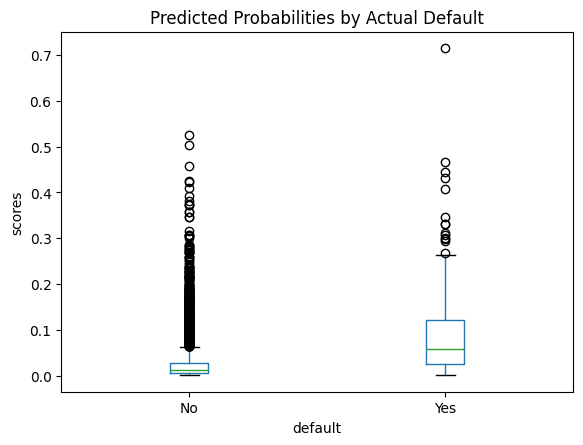

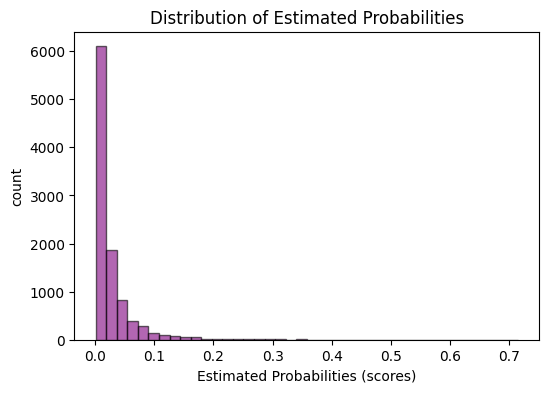

In [99]:
# Predicted probabilities
df["score"] = logit_fit3.predict(df[["balance"]])

# --- Plot 1: Boxplot of predicted scores by default (No vs Yes) ---
plt.figure(figsize=(6,4))
df.boxplot(column="score", by="default", grid=False)
plt.suptitle("")  # remove automatic pandas title
plt.xlabel("default")
plt.ylabel("scores")
plt.title("Predicted Probabilities by Actual Default")
plt.show()

# --- Plot 2: Histogram of predicted probabilities ---
plt.figure(figsize=(6,4))
plt.hist(df["score"], bins=40, color="purple", alpha=0.6, edgecolor="black")
plt.xlabel("Estimated Probabilities (scores)")
plt.ylabel("count")
plt.title("Distribution of Estimated Probabilities")
plt.show()

In [100]:
df_small = df.sample(frac=0.05, random_state=42).copy()


In [101]:
# ----- model: default ~ balance -----
logit_fit = smf.logit("default_binary ~ balance", data=df_small).fit()
print(logit_fit.summary())

# predicted probabilities
df_small["score"] = logit_fit.predict(df_small[["balance"]])

# sanity checks
print("Min/Max predicted probability:", df_small["score"].min(), df_small["score"].max())


Optimization terminated successfully.
         Current function value: 0.040272
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:         default_binary   No. Observations:                  500
Model:                          Logit   Df Residuals:                      498
Method:                           MLE   Df Model:                            1
Date:                Wed, 24 Sep 2025   Pseudo R-squ.:                  0.1357
Time:                        20:57:45   Log-Likelihood:                -20.136
converged:                       True   LL-Null:                       -23.297
Covariance Type:            nonrobust   LLR p-value:                   0.01192
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -8.3106      1.803     -4.609      0.000     -11.845      -4.776
balance        0.0023      0

FN=264, FP=2, TN=9733, TP=1


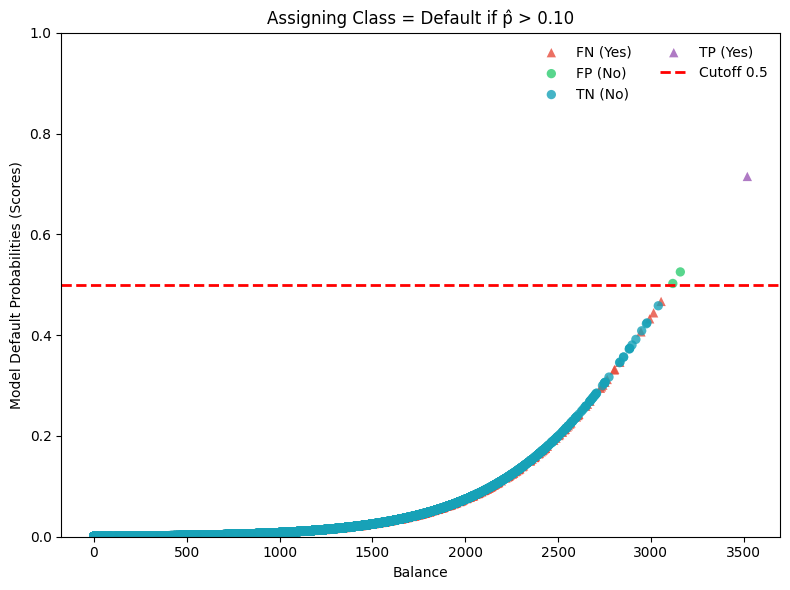

In [102]:
from sklearn.metrics import confusion_matrix
# --- classify at cutoff = 0.50 ---
cutoff = 0.50
df["pred"] = (df["score"] > cutoff).astype(int)

def posneg(row):
    if row["default_binary"] == 1 and row["pred"] == 1: return "TP"
    if row["default_binary"] == 0 and row["pred"] == 1: return "FP"
    if row["default_binary"] == 0 and row["pred"] == 0: return "TN"
    return "FN"

df["PosNeg01"] = df.apply(posneg, axis=1)

# --- confusion counts (FN FP TN TP order like your slide) ---
tn, fp, fn, tp = confusion_matrix(df["default_binary"], df["pred"]).ravel()
print(f"FN={fn}, FP={fp}, TN={tn}, TP={tp}")

# --- plot: color by PosNeg, marker by actual class (0=No ●, 1=Yes ▲) ---
colors = {"TP":"#9b59b6", "FP":"#2ecc71", "TN":"#17a2b8", "FN":"#e74c3c"}
markers = {0:"o", 1:"^"}  # No circle, Yes triangle

plt.figure(figsize=(8,6))
for (posneg_label, actual_class), grp in df.groupby(["PosNeg01","default_binary"]):
    plt.scatter(grp["balance"], grp["score"],
                c=colors[posneg_label], marker=markers[actual_class],
                s=45, alpha=0.8, edgecolor="none",
                label=f"{posneg_label} ({'Yes' if actual_class==1 else 'No'})")

# cutoff line
plt.axhline(cutoff, color="red", linestyle="--", linewidth=2, label=f"Cutoff {cutoff}")

plt.xlabel("Balance")
plt.ylabel("Model Default Probabilities (Scores)")
plt.title("Assigning Class = Default if p̂ > 0.10")
plt.ylim(0, 1)
# merge duplicate legend labels
handles, labels = plt.gca().get_legend_handles_labels()
uniq = dict(zip(labels, handles))
plt.legend(uniq.values(), uniq.keys(), ncol=2, frameon=False)
plt.tight_layout()
plt.show()

FN=264, FP=0, TN=9735, TP=1


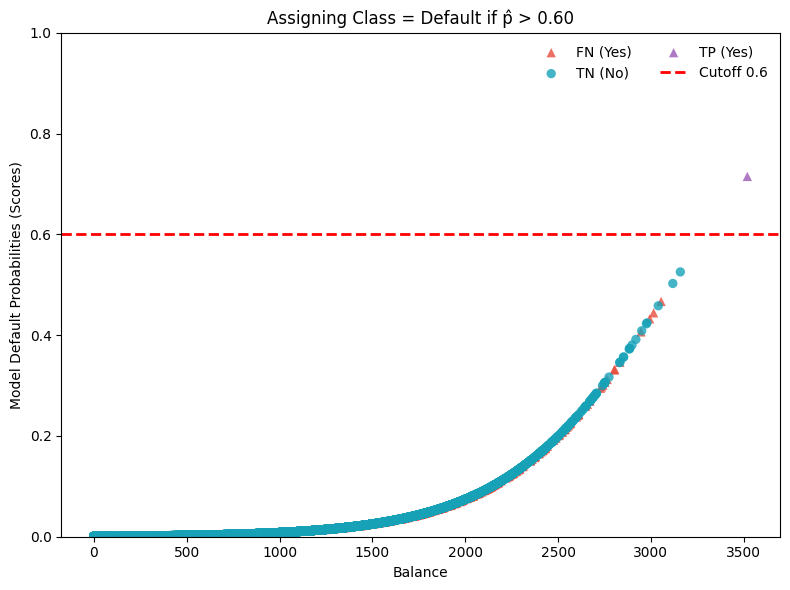

In [103]:
from sklearn.metrics import confusion_matrix
# --- classify at cutoff = 0.60 ---
cutoff = 0.60
df["pred"] = (df["score"] > cutoff).astype(int)

def posneg(row):
    if row["default_binary"] == 1 and row["pred"] == 1: return "TP"
    if row["default_binary"] == 0 and row["pred"] == 1: return "FP"
    if row["default_binary"] == 0 and row["pred"] == 0: return "TN"
    return "FN"

df["PosNeg01"] = df.apply(posneg, axis=1)

# --- confusion counts (FN FP TN TP order like your slide) ---
tn, fp, fn, tp = confusion_matrix(df["default_binary"], df["pred"]).ravel()
print(f"FN={fn}, FP={fp}, TN={tn}, TP={tp}")

# --- plot: color by PosNeg, marker by actual class (0=No ●, 1=Yes ▲) ---
colors = {"TP":"#9b59b6", "FP":"#2ecc71", "TN":"#17a2b8", "FN":"#e74c3c"}
markers = {0:"o", 1:"^"}  # No circle, Yes triangle

plt.figure(figsize=(8,6))
for (posneg_label, actual_class), grp in df.groupby(["PosNeg01","default_binary"]):
    plt.scatter(grp["balance"], grp["score"],
                c=colors[posneg_label], marker=markers[actual_class],
                s=45, alpha=0.8, edgecolor="none",
                label=f"{posneg_label} ({'Yes' if actual_class==1 else 'No'})")

# cutoff line
plt.axhline(cutoff, color="red", linestyle="--", linewidth=2, label=f"Cutoff {cutoff}")

plt.xlabel("Balance")
plt.ylabel("Model Default Probabilities (Scores)")
plt.title("Assigning Class = Default if p̂ > 0.60")
plt.ylim(0, 1)
# merge duplicate legend labels
handles, labels = plt.gca().get_legend_handles_labels()
uniq = dict(zip(labels, handles))
plt.legend(uniq.values(), uniq.keys(), ncol=2, frameon=False)
plt.tight_layout()
plt.show()

FN=260, FP=6, TN=9729, TP=5


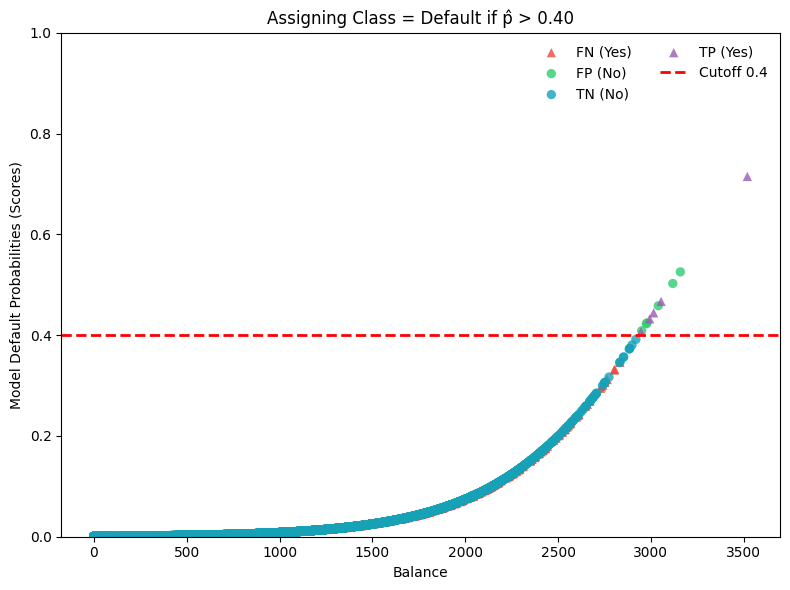

In [104]:
from sklearn.metrics import confusion_matrix
# --- classify at cutoff = 0.40 ---
cutoff = 0.40
df["pred"] = (df["score"] > cutoff).astype(int)

def posneg(row):
    if row["default_binary"] == 1 and row["pred"] == 1: return "TP"
    if row["default_binary"] == 0 and row["pred"] == 1: return "FP"
    if row["default_binary"] == 0 and row["pred"] == 0: return "TN"
    return "FN"

df["PosNeg01"] = df.apply(posneg, axis=1)

# --- confusion counts (FN FP TN TP order like your slide) ---
tn, fp, fn, tp = confusion_matrix(df["default_binary"], df["pred"]).ravel()
print(f"FN={fn}, FP={fp}, TN={tn}, TP={tp}")

# --- plot: color by PosNeg, marker by actual class (0=No ●, 1=Yes ▲) ---
colors = {"TP":"#9b59b6", "FP":"#2ecc71", "TN":"#17a2b8", "FN":"#e74c3c"}
markers = {0:"o", 1:"^"}  # No circle, Yes triangle

plt.figure(figsize=(8,6))
for (posneg_label, actual_class), grp in df.groupby(["PosNeg01","default_binary"]):
    plt.scatter(grp["balance"], grp["score"],
                c=colors[posneg_label], marker=markers[actual_class],
                s=45, alpha=0.8, edgecolor="none",
                label=f"{posneg_label} ({'Yes' if actual_class==1 else 'No'})")

# cutoff line
plt.axhline(cutoff, color="red", linestyle="--", linewidth=2, label=f"Cutoff {cutoff}")

plt.xlabel("Balance")
plt.ylabel("Model Default Probabilities (Scores)")
plt.title("Assigning Class = Default if p̂ > 0.40")
plt.ylim(0, 1)
# merge duplicate legend labels
handles, labels = plt.gca().get_legend_handles_labels()
uniq = dict(zip(labels, handles))
plt.legend(uniq.values(), uniq.keys(), ncol=2, frameon=False)
plt.tight_layout()
plt.show()

In [105]:
from sklearn.metrics import confusion_matrix, classification_report

# y (actual) and design matrix X (must match the formula columns)
y = df["default_binary"]
X = df[["balance", "income", "student_bin"]]   # adjust to your formula

# probs from statsmodels:
y_prob = logit_fit.predict(X)   # <-- not predict_proba

# classify at cutoff = 0.3
cutoff = 0.30
y_pred = (y_prob >= cutoff).astype(int)

# confusion matrix
cm = confusion_matrix(y, y_pred)
cm_df = pd.DataFrame(cm,
                     index=["Actual 0 (No)", "Actual 1 (Yes)"],
                     columns=["Pred 0 (No)", "Pred 1 (Yes)"])
print("Confusion Matrix at cutoff = 0.30")
print(cm_df)

print("\nClassification Report:")
print(classification_report(y, y_pred, digits=3))

Confusion Matrix at cutoff = 0.30
                Pred 0 (No)  Pred 1 (Yes)
Actual 0 (No)          9735             0
Actual 1 (Yes)          264             1

Classification Report:
              precision    recall  f1-score   support

           0      0.974     1.000     0.987      9735
           1      1.000     0.004     0.008       265

    accuracy                          0.974     10000
   macro avg      0.987     0.502     0.497     10000
weighted avg      0.974     0.974     0.961     10000



AUC: 0.8004322082352144


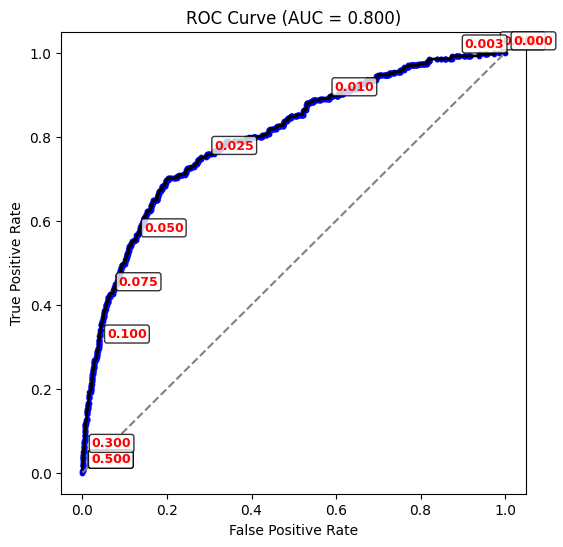

In [130]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# true labels
y_true = df["default_binary"]

# predicted probabilities
y_scores = df["score"]  

# compute ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_scores)

# compute AUC
auc = roc_auc_score(y_true, y_scores)
print("AUC:", auc)

# plot ROC curve
fig1, ax = plt.subplots(figsize=(6,6))

# plot ROC curve
ax.plot(fpr, tpr, color="black", linewidth=2)
ax.plot([0,1], [0,1], linestyle="--", color="gray")  # diagonal baseline
ax.scatter(fpr, tpr, s=10, color="blue")  # optional: mark cutoff points

# label some cutoff points# label some cutoff points
for cutoff in [0.99, 0.9, 0.7, 0.5, 0.3, 0.1, 0.05, 0.075, 0.025,0.01, 0.001, 0.003, 0.0]:
    # Find closest threshold value
    if cutoff == 0.0:
        idx = len(thresholds) - 1  # Last threshold is usually 0.0
    else:
        idx = np.argmin(np.abs(thresholds - cutoff))
    
    # Add text with slight offset and background for visibility
    ax.text(fpr[idx] + 0.02, tpr[idx] + 0.02, f"{cutoff:.3f}", 
            fontsize=9, color='red', weight='bold',
            bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curve (AUC = {auc:.3f})")
plt.show(fig1)

---

## Lab 2 — Logistic Regression in Python (Time permitting)

**Data columns assumed:** `default` (Yes/No), `student` (Yes/No), `balance`, `income`.



### 1) Estimate a logistic regression model
Fit a logistic regression of `default` on the predictors `income`, `student`, and `balance`.  
Store this model as **`logit_mod4`**.

In [107]:
logit_mod4 = smf.logit("default_binary ~ balance + income + student", data=df).fit()
print(logit_mod4.summary())

Optimization terminated successfully.
         Current function value: 0.103238
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:         default_binary   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9996
Method:                           MLE   Df Model:                            3
Date:                Wed, 24 Sep 2025   Pseudo R-squ.:                  0.1563
Time:                        20:57:46   Log-Likelihood:                -1032.4
converged:                       True   LL-Null:                       -1223.6
Covariance Type:            nonrobust   LLR p-value:                 1.451e-82
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -6.5782      0.269    -24.473      0.000      -7.105      -6.051
student[T.Yes]   

### 2) Generate predicted probabilities
Use the fitted model to generate predicted probabilities (scores) for the training data.  
Store them as a new column called **`p_hat`**.

In [121]:

# y (actual) and design matrix X (must match the formula columns)
y = df["default_binary"]
X = df[["balance", "income", "student"]]   # adjust to your formula

# probs from statsmodels:
y_prob = logit_mod4.predict(X)  
print(y_prob.head(5)) 

0   0.059466
1   0.031773
2   0.009074
3   0.063215
4   0.013506
dtype: float64


### 3) Create a results DataFrame
Build a DataFrame with the following columns:
- **`y_true`** → actual class (`1` = default, `0` = no default)  
- **`p_hat`** → predicted probability $\hat{p} = \Pr(Y=1 \mid X)$  
- **`y_pred`** → predicted class using a cutoff of **0.3**


In [135]:

cutoff = 0.30
y_pred = (y_prob >= cutoff).astype(int)

data = pd.DataFrame()
data['y_true'] = y
data['y_pred'] = y_pred
data[X.columns] = X

data.head()


,y_true,y_pred,balance,income,student
0,0,0,1905.040000,76094.340000,No
1,0,0,1677.960000,102957.100000,No
2,0,0,1192.650000,137960.580000,No
3,0,0,1768.440000,10000.000000,No
4,0,0,1243.930000,30979.300000,Yes


### 4) Generate a confusion matrix
Use your results DataFrame and the **0.3 cutoff** to compute a confusion matrix.


In [123]:

# confusion matrix
cm = confusion_matrix(y, y_pred)
cm_df = pd.DataFrame(cm,
                     index=["Actual 0 (No)", "Actual 1 (Yes)"],
                     columns=["Pred 0 (No)", "Pred 1 (Yes)"])
print("Confusion Matrix at cutoff = 0.30")
print(cm_df)

Confusion Matrix at cutoff = 0.30
                Pred 0 (No)  Pred 1 (Yes)
Actual 0 (No)          9712            23
Actual 1 (Yes)          254            11



### 5) Count false positives
How many **false positives (FP)** did your model produce?  
*(FP = model predicts default = 1, but actual default = 0)*

In [131]:
print(23/10000)

0.0023


## Answer

There are 23 false positives which means there is a 0.23% chance there is a false positive

### 6) Plot an ROC curve
Use your fitted model to plot an ROC curve.  
Label the axes as **False Positive Rate** and **True Positive Rate**.

AUC: 0.8052144082332762


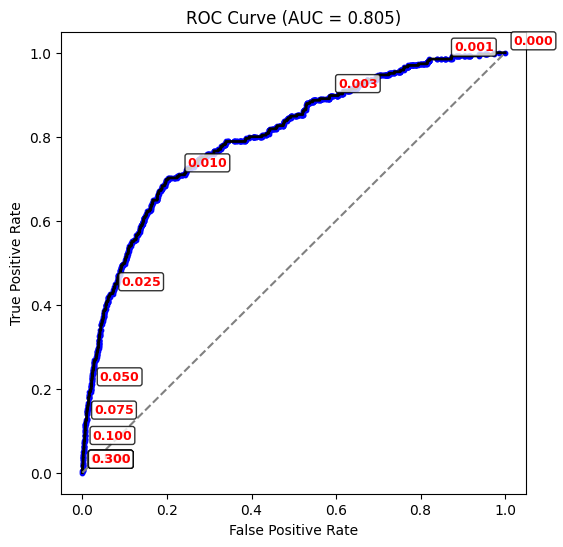

In [128]:
auc = roc_auc_score(y, y_prob)
print("AUC:", auc)

# Create figure and axis
fig, ax = plt.subplots(figsize=(6,6))

# plot ROC curve
ax.plot(fpr, tpr, color="black", linewidth=2)
ax.plot([0,1], [0,1], linestyle="--", color="gray")  # diagonal baseline
ax.scatter(fpr, tpr, s=10, color="blue")  # optional: mark cutoff points

# label some cutoff points# label some cutoff points
for cutoff in [0.99, 0.9, 0.7, 0.5, 0.3, 0.1, 0.05, 0.075, 0.025,0.01, 0.001, 0.003, 0.0]:
    # Find closest threshold value
    if cutoff == 0.0:
        idx = len(thresholds) - 1  # Last threshold is usually 0.0
    else:
        idx = np.argmin(np.abs(thresholds - cutoff))
    
    # Add text with slight offset and background for visibility
    ax.text(fpr[idx] + 0.02, tpr[idx] + 0.02, f"{cutoff:.3f}", 
            fontsize=9, color='red', weight='bold',
            bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curve (AUC = {auc:.3f})")
plt.show(fig)

### 7) Calculate the AUC
Compute the **Area Under the Curve (AUC)** for this model.  
Is your AUC closer to **0.5 (random guessing)** or **1.0 (perfect model)**?

### Answer 

the model is at 0.805 so it is better than random guessing but there is not close to perfect

AUC of 0.805 is ok